<a href="https://colab.research.google.com/github/20KaRaKuM20/NM/blob/main/%D0%BB%D1%8010_%D0%92%D0%B8%D1%81%D0%BE%D1%86%D1%8C%D0%BA%D0%B8%D0%B9_%D0%92%D0%BE%D0%BB%D0%BE%D0%B4%D0%B8%D0%BC%D0%B8%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

f'(x) = -cos(x) + 1/(x + 1)
f''(x) = sin(x) - 1/(x + 1)**2
f'''(x) = cos(x) + 2/(x + 1)**3
------------------------------
f(0) = 0
T(x) = 0.5*x**2*(x - 1.0)
------------------------------


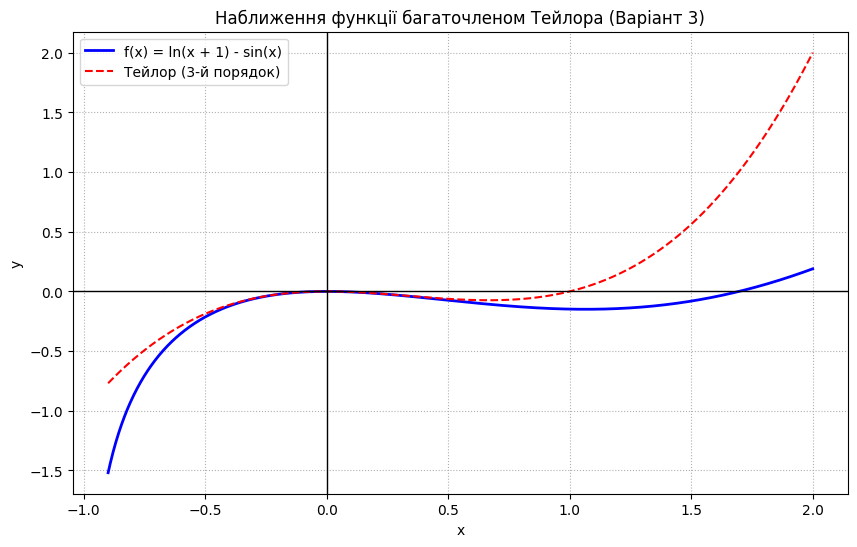

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Задаємо символьну змінну x та функцію f(x)
x = sp.symbols('x')
f = sp.ln(x + 1) - sp.sin(x)

# Знаходимо перші три похідні
f1 = sp.diff(f, x)
f2 = sp.diff(f1, x)
f3 = sp.diff(f2, x)

# Виводимо похідні
print("f'(x) =", f1)
print("f''(x) =", f2)
print("f'''(x) =", f3)

# Знаходимо значення функції та її похідних в точці x=0
x0 = 0
f_x0 = f.subs(x, x0).evalf()
f1_x0 = f1.subs(x, x0).evalf()
f2_x0 = f2.subs(x, x0).evalf()
f3_x0 = f3.subs(x, x0).evalf()

# Обчислюємо значення многочлена Тейлора в точці x=0 (3-й порядок)
T = f_x0 + f1_x0*(x-x0) + (f2_x0/2)*(x-x0)**2 + (f3_x0/6)*(x-x0)**3

# Виводимо значення функції та наближення
print("-" * 30)
print(f"f(0) = {f_x0.round(3)}")
print(f"T(x) = {sp.simplify(T).evalf(3)}") # спрощений вигляд многочлена
print("-" * 30)

# Будуємо графіки
# Область визначення ln(x+1) це x > -1, тому беремо проміжок від -0.9 до 2
x_vals = np.linspace(-0.9, 2, 1000)
f_func = sp.lambdify(x, f, "numpy")
T_func = sp.lambdify(x, T, "numpy")

f_vals = f_func(x_vals)
T_vals = T_func(x_vals)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, f_vals, label='f(x) = ln(x + 1) - sin(x)', color='blue', linewidth=2)
ax.plot(x_vals, T_vals, label='Тейлор (3-й порядок)', color='red', linestyle='--')

ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Наближення функції багаточленом Тейлора (Варіант 3)")
plt.grid(True, linestyle=':')
plt.show()

Багаточлен Тейлора (3 степеня):
         3          2
0.4776 x - 0.5013 x + 0.0001166 x - 6.092e-18


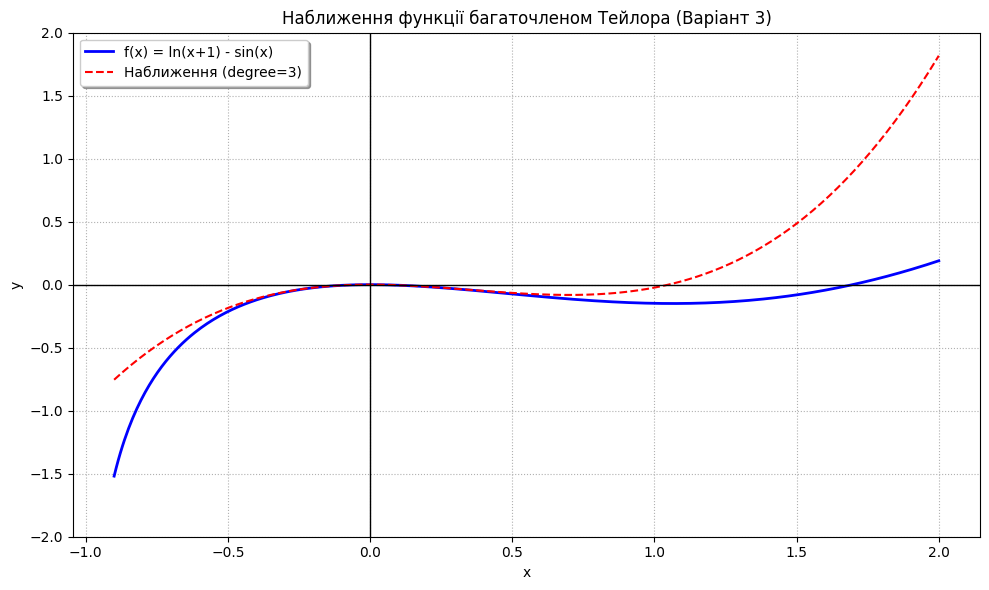

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import approximate_taylor_polynomial

# 1. Змінюємо функцію на f(x) = ln(x + 1) - sin(x)
def f(x):
    return np.log(x + 1) - np.sin(x)

# 2. Змінюємо діапазон x.
# Логарифм визначений при x > -1, тому почнемо з -0.9
x = np.linspace(-0.9, 2.0, num=400)

plt.figure(figsize=(10, 6))
plt.plot(x, f(x), label="f(x) = ln(x+1) - sin(x)", color='blue', lw=2)

degree = 3
# Обчислюємо багаточлен Тейлора в точці 0 (x0=0)
# масштаб (scale) зазвичай береться невеликим для точності похідних
taylor = approximate_taylor_polynomial(f, 0, degree, scale=0.1)

print(f'Багаточлен Тейлора ({degree} степеня):\n', taylor)

# 3. Візуалізація
plt.plot(x, taylor(x), label=f"Наближення (degree={degree})", color='red', linestyle='--')

plt.legend(loc='upper left', shadow=True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Наближення функції багаточленом Тейлора (Варіант 3)")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.ylim(-2, 2) # обмежимо по осі y для кращого вигляду
plt.tight_layout()
plt.grid(True, linestyle=':')
plt.show()